# Census Income: Customer Segmentation

This notebook is different from the classification one.
Instead of predicting who earns what, the goal here is to discover natural groups
in the population that the retail client can market to differently.

The income label is not used to guide clustering — I want to find groups
based purely on who people are and how they live, then check how income
distributes across those groups afterward.

## 1. Imports

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('all good')

all good


## 2. Load Data

In [43]:
# loading the cleaned csv from notebook 01
# not using the one-hot encoded version from notebook 02
# one-hot creates too many columns and distance calculations get noisy

df = pd.read_csv('../data/census_cleaned.csv')

print(f'shape: {df.shape}')
print(df['label'].value_counts())

shape: (199523, 42)
label
0    187141
1     12382
Name: count, dtype: int64


## 3. Feature Analysis

Before picking features I want to understand each one.
Checking sparsity and unique values so I have evidence for every drop decision.

In [44]:
# checking numeric features for sparsity
# if most values are zero the feature won't separate clusters meaningfully

print('NUMERIC FEATURES — % zeros:')
numeric_check = ['wage per hour', 'capital gains', 'capital losses',
                 'dividends from stocks', 'weeks worked in year',
                 'num persons worked for employer', 'age', 'family members under 18']

for col in numeric_check:
    zero_pct = (df[col] == 0).mean() * 100
    print(f'  {col:40} {zero_pct:.1f}% zeros')

# checking categorical features for unique value count
# too many unique values = noise for KMeans distance calculations

print('\nCATEGORICAL FEATURES — unique value count:')
cat_check = [
    'major occupation code', 'detailed occupation recode',
    'major industry code', 'detailed industry recode',
    'education', 'marital stat', 'class of worker',
    'race', 'sex', 'citizenship', 'hispanic origin',
    'country of birth self', 'tax filer stat',
    'full or part time employment stat',
    'detailed household summary in household',
    'enroll in edu inst last wk', 'member of a labor union',
    'reason for unemployment', 'live in this house 1 year ago'
]
for col in cat_check:
    if col in df.columns:
        print(f'  {col:45} {df[col].nunique()} unique values')

NUMERIC FEATURES — % zeros:
  wage per hour                            94.3% zeros
  capital gains                            96.3% zeros
  capital losses                           98.0% zeros
  dividends from stocks                    89.4% zeros
  weeks worked in year                     48.1% zeros
  num persons worked for employer          48.1% zeros
  age                                      1.4% zeros
  family members under 18                  0.0% zeros

CATEGORICAL FEATURES — unique value count:
  major occupation code                         15 unique values
  detailed occupation recode                    47 unique values
  major industry code                           24 unique values
  detailed industry recode                      52 unique values
  education                                     17 unique values
  marital stat                                  7 unique values
  class of worker                               9 unique values
  race                               

## 4. Feature Selection Decisions

Based on the analysis above, here is what I am keeping and why.

In [45]:
print('FEATURE SELECTION DECISIONS')
print('=' * 60)

print('\ndropped - too sparse (over 89% zeros):')
print('  wage per hour       94.3% zeros - most people are salaried')
print('  capital gains raw   96.3% zeros - replacing with binary flag')
print('  capital losses      98.0% zeros - almost no variation')
print('  dividends raw       89.4% zeros - replacing with binary flag')

print('\ndropped - too many unique values (noisy for KMeans):')
print('  country of birth columns  42 unique values each')
print('  detailed occupation recode  47 unique values')
print('  detailed industry recode    52 unique values')
print('  these are numeric lookup codes — code 278 is not more than code 34')

print('\ndropped - overlaps with a better feature:')
print('  hispanic origin           overlaps with citizenship')
print('  detailed household summary  overlaps with marital stat')
print('  enroll in edu inst          overlaps with education')
print('  member of a labor union     mostly not in universe')
print('  reason for unemployment     mostly not in universe')
print('  live in this house 1 year   migration related, low signal')

print('\ndropped - ethical concern:')
print('  race       risk of creating race-defined marketing segments')
print('  citizenship low signal, partially captured by tax filer stat')

print('\nkept - strong signal from EDA:')
print('  age, sex, education, marital stat, class of worker')
print('  major occupation, major industry, employment status')
print('  weeks worked, num persons worked for employer')
print('  tax filer stat')
print('  has_capital_gains and has_dividends (binary flags)')

# creating binary investment flags
# from EDA: having ANY capital gains = 7x more likely to be high earner
# the binary flag captures this better than the sparse raw dollar amount
df['has_capital_gains'] = (df['capital gains'] > 0).astype(int)
df['has_dividends']     = (df['dividends from stocks'] > 0).astype(int)

print(f'\nbinary flags created:')
print(f'  has_capital_gains: {df["has_capital_gains"].mean()*100:.1f}% have any capital gains')
print(f'  has_dividends:     {df["has_dividends"].mean()*100:.1f}% have any dividend income')

FEATURE SELECTION DECISIONS

dropped - too sparse (over 89% zeros):
  wage per hour       94.3% zeros - most people are salaried
  capital gains raw   96.3% zeros - replacing with binary flag
  capital losses      98.0% zeros - almost no variation
  dividends raw       89.4% zeros - replacing with binary flag

dropped - too many unique values (noisy for KMeans):
  country of birth columns  42 unique values each
  detailed occupation recode  47 unique values
  detailed industry recode    52 unique values
  these are numeric lookup codes — code 278 is not more than code 34

dropped - overlaps with a better feature:
  hispanic origin           overlaps with citizenship
  detailed household summary  overlaps with marital stat
  enroll in edu inst          overlaps with education
  member of a labor union     mostly not in universe
  reason for unemployment     mostly not in universe
  live in this house 1 year   migration related, low signal

dropped - ethical concern:
  race       risk of

In [46]:
# final 14 features based on the analysis above

seg_features = [
    # demographics
    'age',
    'sex',
    'education',
    'marital stat',
    # employment
    'class of worker',
    'major occupation code',
    'major industry code',
    'full or part time employment stat',
    'weeks worked in year',
    'num persons worked for employer',
    # financial signals
    'has_capital_gains',
    'has_dividends',
    'tax filer stat',
    # household
    'family members under 18'
]

df_seg = df[seg_features + ['label']].copy()
print(f'final feature count: {len(seg_features)}')
print(f'shape: {df_seg.shape}')

final feature count: 14
shape: (199523, 15)


## 5. Distribution Check

Before preprocessing I want to check a few features that looked unusual.
This guides how to handle them properly.

In [47]:
# weeks worked has a bimodal problem — 48% are zeros (not working)
# rest spread from 1-52 weeks
# this would confuse KMeans so I'll bin it into 4 meaningful groups

print('weeks worked in year — top values:')
print(df_seg['weeks worked in year'].value_counts().sort_index().head(10))

print('\neducation — value counts (to confirm ordinal encoding order):')
print(df['education'].str.strip().value_counts())

weeks worked in year — top values:
weeks worked in year
0    95983
1      464
2      458
3      417
4      757
5      309
6      646
7      152
8     1126
9      239
Name: count, dtype: int64

education — value counts (to confirm ordinal encoding order):
education
High school graduate                      48407
Children                                  47422
Some college but no degree                27820
Bachelors degree(BA AB BS)                19865
7th and 8th grade                          8007
10th grade                                 7557
11th grade                                 6876
Masters degree(MA MS MEng MEd MSW MBA)     6541
9th grade                                  6230
Associates degree-occup /vocational        5358
Associates degree-academic program         4363
5th or 6th grade                           3277
12th grade no diploma                      2126
1st 2nd 3rd or 4th grade                   1799
Prof school degree (MD DDS DVM LLB JD)     1793
Doctorate degre

## 6. Preprocessing

Two improvements over standard label encoding:
1. Ordinal encoding for education — preserves natural order from Children to PhD
2. Binning weeks worked — removes bimodal distortion

In [48]:
# imputing missing values first
for col in df_seg.select_dtypes(include='object').columns:
    df_seg[col] = df_seg[col].str.strip()
    df_seg[col].fillna(df_seg[col].mode()[0], inplace=True)

for col in df_seg.select_dtypes(include='number').columns:
    df_seg[col].fillna(df_seg[col].median(), inplace=True)

print(f'nulls remaining: {df_seg.isnull().sum().sum()}')

nulls remaining: 0


In [49]:
# ordinal encoding for education
# regular label encoding would assign random numbers — meaningless distances
# ordinal encoding preserves the real order: Children < high school < bachelors < phd

edu_order = {
    'Children': 0, 'Less than 1st grade': 1, '1st 2nd 3rd or 4th grade': 2,
    '5th or 6th grade': 3, '7th and 8th grade': 4, '9th grade': 5,
    '10th grade': 6, '11th grade': 7, '12th grade no diploma': 8,
    'High school graduate': 9, 'Some college but no degree': 10,
    'Associates degree-occup /vocational': 11, 'Associates degree-academic program': 12,
    'Bachelors degree(BA AB BS)': 13, 'Masters degree(MA MS MEng MEd MSW MBA)': 14,
    'Doctorate degree(PhD EdD)': 15, 'Prof school degree (MD DDS DVM LLB JD)': 16
}

df_seg['education'] = df_seg['education'].map(edu_order)
print('education ordinal encoded (0=Children to 16=Professional degree)')
print(df_seg['education'].value_counts().sort_index())

education ordinal encoded (0=Children to 16=Professional degree)
education
0     47422
1       819
2      1799
3      3277
4      8007
5      6230
6      7557
7      6876
8      2126
9     48407
10    27820
11     5358
12     4363
13    19865
14     6541
15     1263
16     1793
Name: count, dtype: int64


In [50]:
# binning weeks worked into 4 meaningful groups
# this removes the bimodal distortion from having 48% zeros
# 0 = not working, 1 = part year, 2 = most of year, 3 = full year

df_seg['weeks worked in year'] = pd.cut(
    df_seg['weeks worked in year'],
    bins=[-1, 0, 26, 51, 52],
    labels=[0, 1, 2, 3]
).astype(int)

print('weeks worked binned:')
print(df_seg['weeks worked in year'].value_counts().sort_index())
print('0=not working, 1=part year (1-26 wks), 2=most of year (27-51 wks), 3=full year (52 wks)')

weeks worked binned:
weeks worked in year
0    95983
1    15216
2    18010
3    70314
Name: count, dtype: int64
0=not working, 1=part year (1-26 wks), 2=most of year (27-51 wks), 3=full year (52 wks)


In [51]:
# label encoding remaining categorical features
# using label encoding (not one-hot) to keep feature count manageable
# one-hot on categoricals with 15-24 unique values would explode the dimensions

df_encoded = df_seg.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include='object').columns:
    if col == 'label':
        continue
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print('label encoding done')
print(f'shape: {df_encoded.shape}')

label encoding done
shape: (199523, 15)


In [52]:
# separating features from label
# keeping label out of clustering — this is unsupervised
X_seg = df_encoded[seg_features]
y_seg = df_encoded['label']

# scaling is critical for KMeans
# without it age (0-90) would completely dominate binary features (0-1)
scaler_seg = StandardScaler()
X_scaled   = scaler_seg.fit_transform(X_seg)

print(f'features going into clustering: {X_scaled.shape[1]}')
print('scaling done')

features going into clustering: 14
scaling done


## 7. PCA — Dimensionality Check

Reducing 14 features to 2 dimensions for visualization.
Clustering will still happen on all 14 features — PCA is just for the scatter plot.

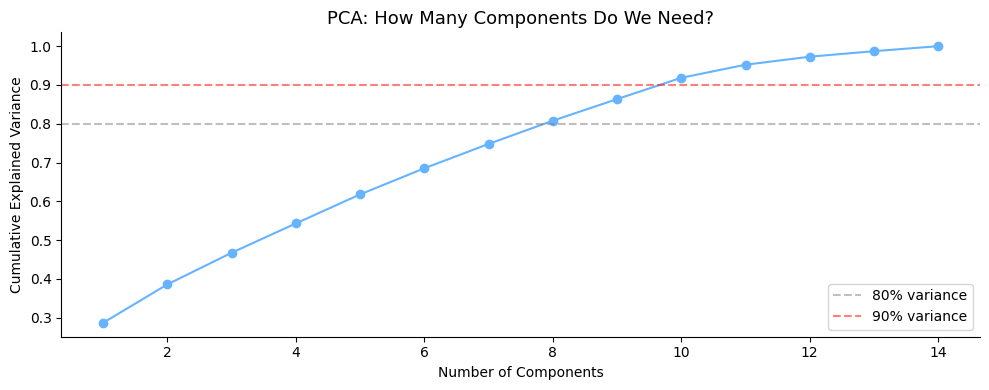

need 8 components for 80% variance
need 10 components for 90% variance
2 components explain 38.6% of variance
clustering on all 14 features — 2D only for visualization


In [53]:
# checking how many components are needed to explain most variance
pca_full = PCA(n_components=14)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 15), cumvar, marker='o', color='#66b3ff')
plt.axhline(y=0.80, color='gray', linestyle='--', alpha=0.5, label='80% variance')
plt.axhline(y=0.90, color='red',  linestyle='--', alpha=0.5, label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: How Many Components Do We Need?', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../plots/plot_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1
print(f'need {n_80} components for 80% variance')
print(f'need {n_90} components for 90% variance')

# 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_scaled)
print(f'2 components explain {pca_2d.explained_variance_ratio_.sum():.1%} of variance')
print('clustering on all 14 features — 2D only for visualization')

## 8. Finding the Right Number of Clusters

Using elbow method and silhouette score together.
The elbow tells us where adding more clusters stops helping.
The silhouette score tells us how well separated clusters actually are.

running elbow method...
  k=2 done
  k=3 done
  k=4 done
  k=5 done
  k=6 done
  k=7 done
  k=8 done
  k=9 done
  k=10 done


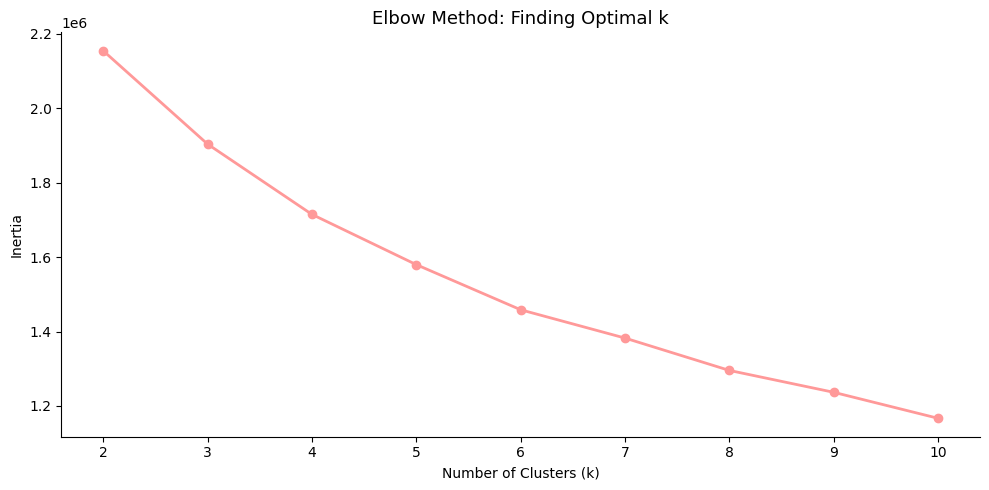

curve flattens around k=5 to k=6 — no sharp elbow, which is common with demographic data


In [54]:
print('running elbow method...')
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'  k={k} done')

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', color='#ff9999', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Finding Optimal k', fontsize=13)
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../plots/plot_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('curve flattens around k=5 to k=6 — no sharp elbow, which is common with demographic data')

running silhouette analysis...
  k=2 | score: 0.2408
  k=3 | score: 0.2455
  k=4 | score: 0.2645
  k=5 | score: 0.2717
  k=6 | score: 0.2780
  k=7 | score: 0.2769
  k=8 | score: 0.2876
  k=9 | score: 0.2877
  k=10 | score: 0.2797


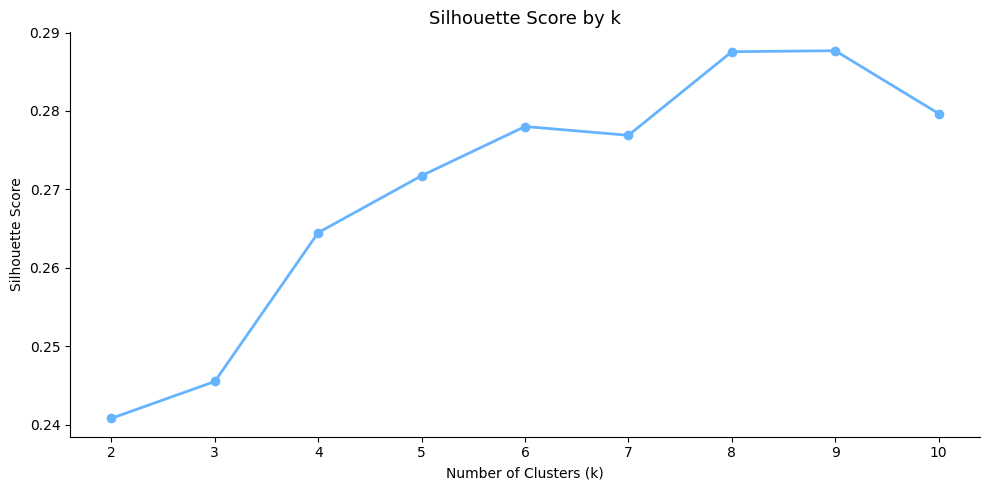

In [55]:
print('running silhouette analysis...')
sil_scores = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f'  k={k} | score: {score:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores, marker='o', color='#66b3ff', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k', fontsize=13)
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../plots/plot_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# documenting the k=5 decision clearly
# silhouette peaks around k=8-9 but the differences are very small
# k=5 vs k=8 difference is only ~0.016 — not worth doubling the number of segments
# elbow curve also flattens around k=5
# and 5 segments is the maximum a retail marketing team can act on meaningfully

print('combining findings from both methods:')
for k, s in zip(k_range, sil_scores):
    print(f'  k={k} | silhouette: {s:.4f}')

print('\nelbow method: curve flattens around k=5')
print('silhouette: keeps improving slightly but differences become marginal after k=5')
print('business constraint: max 5-6 segments for a retail marketing team to act on')
print('\ndecision: k=5')

combining findings from both methods:
  k=2 | silhouette: 0.2408
  k=3 | silhouette: 0.2455
  k=4 | silhouette: 0.2645
  k=5 | silhouette: 0.2717
  k=6 | silhouette: 0.2780
  k=7 | silhouette: 0.2769
  k=8 | silhouette: 0.2876
  k=9 | silhouette: 0.2877
  k=10 | silhouette: 0.2797

elbow method: curve flattens around k=5
silhouette: keeps improving slightly but differences become marginal after k=5
business constraint: max 5-6 segments for a retail marketing team to act on

decision: k=5


## 9. Final KMeans Model

In [57]:
FINAL_K = 5

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_seg['cluster'] = cluster_labels

print(f'cluster sizes:')
print(df_seg['cluster'].value_counts().sort_index())
print(f'\nfinal silhouette score: {silhouette_score(X_scaled, cluster_labels, sample_size=5000, random_state=42):.4f}')

cluster sizes:
cluster
0    39338
1    55095
2    51083
3     7379
4    46628
Name: count, dtype: int64

final silhouette score: 0.2717


## 10. Visualize Clusters

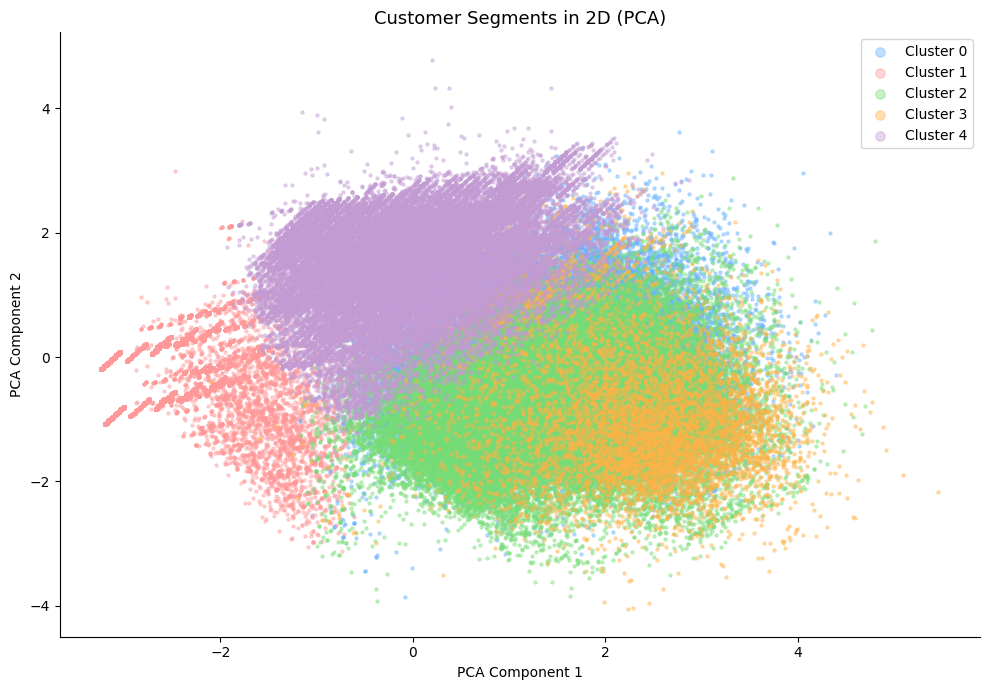

note: 2D only captures 38.6% of variance — some overlap is expected
clusters are more separated in the full 14-dimensional space


In [58]:
colors = ['#66b3ff', '#ff9999', '#77dd77', '#ffb347', '#c39bd3']

plt.figure(figsize=(10, 7))
for i in range(FINAL_K):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.4, s=5)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments in 2D (PCA)', fontsize=13)
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../plots/plot_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('note: 2D only captures 38.6% of variance — some overlap is expected')
print('clusters are more separated in the full 14-dimensional space')

## 11. Cluster Profiling

This is the most important section.
The clusters are only useful if I can describe who is in them.

In [59]:
# numeric averages per cluster
# education and weeks worked are now encoded so I'll map them back to labels in the summary

numeric_cols = ['age', 'weeks worked in year', 'education',
                'num persons worked for employer', 'has_capital_gains', 'has_dividends']

print('average numeric values per cluster:')
print(df_seg.groupby('cluster')[numeric_cols].mean().round(2).to_string())
print('\nnote: weeks worked 0=not working, 1=part year, 2=most year, 3=full year')
print('note: education 0=Children, 9=high school, 13=bachelors, 16=professional degree')

average numeric values per cluster:
           age  weeks worked in year  education  num persons worked for employer  has_capital_gains  has_dividends
cluster                                                                                                           
0        39.07                  2.60       9.80                             3.90                0.0           0.15
1         8.25                  0.06       0.75                             0.13                0.0           0.00
2        38.37                  2.61      10.26                             3.83                0.0           0.15
3        48.50                  2.23      10.73                             3.21                1.0           0.28
4        55.19                  0.15       8.16                             0.22                0.0           0.12

note: weeks worked 0=not working, 1=part year, 2=most year, 3=full year
note: education 0=Children, 9=high school, 13=bachelors, 16=professional degree


income rate and size per cluster:
  cluster 0: 39,338 people (19.7%) | 9.3% earn over $50K
  cluster 1: 55,095 people (27.6%) | 0.0% earn over $50K
  cluster 2: 51,083 people (25.6%) | 11.4% earn over $50K
  cluster 3: 7,379 people (3.7%) | 32.7% earn over $50K
  cluster 4: 46,628 people (23.4%) | 1.1% earn over $50K


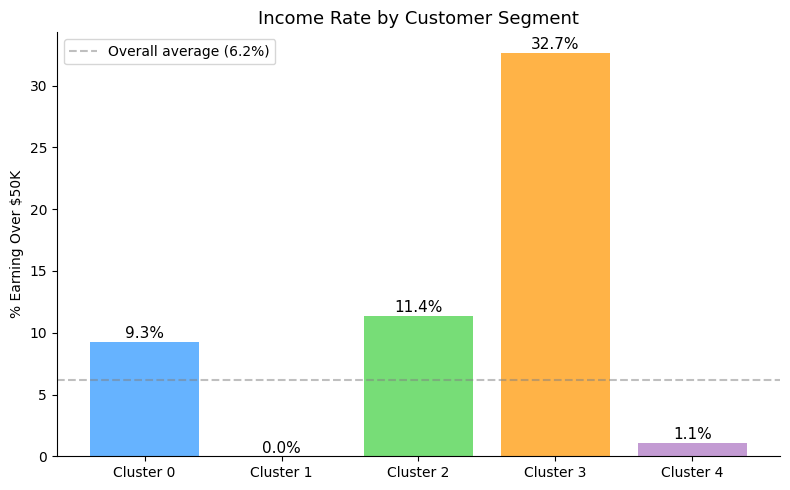

In [60]:
# income rate per cluster — the key business metric

income_by_cluster = df_seg.groupby('cluster')['label'].mean() * 100
cluster_size      = df_seg.groupby('cluster').size()
cluster_pct       = (cluster_size / len(df_seg) * 100).round(1)

print('income rate and size per cluster:')
for i in range(FINAL_K):
    print(f'  cluster {i}: {cluster_size[i]:,} people ({cluster_pct[i]}%) | '
          f'{income_by_cluster[i]:.1f}% earn over $50K')

plt.figure(figsize=(8, 5))
bars = plt.bar([f'Cluster {i}' for i in range(FINAL_K)],
               income_by_cluster.values, color=colors)
plt.axhline(y=6.2, color='gray', linestyle='--', alpha=0.5, label='Overall average (6.2%)')
plt.ylabel('% Earning Over $50K')
plt.title('Income Rate by Customer Segment', fontsize=13)
plt.legend()
for bar, val in zip(bars, income_by_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/plot_income_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# categorical profile — most common value per cluster
# mapping education back to readable labels for display

edu_map = {
    0: 'Children', 1: 'Less than 1st grade', 2: '1st-4th grade',
    3: '5th-6th grade', 4: '7th-8th grade', 5: '9th grade',
    6: '10th grade', 7: '11th grade', 8: '12th grade no diploma',
    9: 'High school graduate', 10: 'Some college',
    11: 'Associates (vocational)', 12: 'Associates (academic)',
    13: 'Bachelors', 14: 'Masters', 15: 'Doctorate', 16: 'Professional degree'
}

print('dominant category per cluster:')

print('\neducation (most common):')
for i in range(FINAL_K):
    edu_num = df_seg[df_seg['cluster'] == i]['education'].mode()[0]
    print(f'  cluster {i}: {edu_map.get(int(edu_num), edu_num)}')

for col in ['sex', 'marital stat', 'class of worker', 'major occupation code', 'tax filer stat']:
    print(f'\n{col}:')
    for i in range(FINAL_K):
        top = df_seg[df_seg['cluster'] == i][col].mode()[0]
        print(f'  cluster {i}: {top}')

dominant category per cluster:

education (most common):
  cluster 0: High school graduate
  cluster 1: Children
  cluster 2: High school graduate
  cluster 3: High school graduate
  cluster 4: High school graduate

sex:
  cluster 0: Female
  cluster 1: Male
  cluster 2: Male
  cluster 3: Male
  cluster 4: Female

marital stat:
  cluster 0: Married-civilian spouse present
  cluster 1: Never married
  cluster 2: Married-civilian spouse present
  cluster 3: Married-civilian spouse present
  cluster 4: Married-civilian spouse present

class of worker:
  cluster 0: Private
  cluster 1: Not in universe
  cluster 2: Private
  cluster 3: Private
  cluster 4: Not in universe

major occupation code:
  cluster 0: Adm support including clerical
  cluster 1: Not in universe
  cluster 2: Professional specialty
  cluster 3: Not in universe
  cluster 4: Not in universe

tax filer stat:
  cluster 0: Joint both under 65
  cluster 1: Nonfiler
  cluster 2: Joint both under 65
  cluster 3: Joint both unde

## 12. Full Cluster Summary

In [62]:
print('CLUSTER SUMMARY')
print('=' * 70)

for i in range(FINAL_K):
    c          = df_seg[df_seg['cluster'] == i]
    edu_num    = c['education'].mode()[0]
    edu_label  = edu_map.get(int(edu_num), str(edu_num))
    weeks_mode = c['weeks worked in year'].mode()[0]
    weeks_map  = {0: 'not working', 1: 'part year', 2: 'most of year', 3: 'full year'}

    print(f'\nCLUSTER {i}')
    print(f'  size:             {len(c):,} ({len(c)/len(df_seg)*100:.1f}% of dataset)')
    print(f'  income >$50K:     {c["label"].mean()*100:.1f}%')
    print(f'  avg age:          {c["age"].mean():.0f}')
    print(f'  works:            {weeks_map.get(weeks_mode, weeks_mode)}')
    print(f'  top education:    {edu_label}')
    print(f'  top sex:          {c["sex"].mode()[0]}')
    print(f'  top marital:      {c["marital stat"].mode()[0]}')
    print(f'  top occupation:   {c["major occupation code"].mode()[0]}')
    print(f'  top worker class: {c["class of worker"].mode()[0]}')
    print(f'  has cap gains:    {c["has_capital_gains"].mean()*100:.0f}% of cluster')
    print(f'  has dividends:    {c["has_dividends"].mean()*100:.0f}% of cluster')
    print('-' * 70)

CLUSTER SUMMARY

CLUSTER 0
  size:             39,338 (19.7% of dataset)
  income >$50K:     9.3%
  avg age:          39
  works:            full year
  top education:    High school graduate
  top sex:          Female
  top marital:      Married-civilian spouse present
  top occupation:   Adm support including clerical
  top worker class: Private
  has cap gains:    0% of cluster
  has dividends:    15% of cluster
----------------------------------------------------------------------

CLUSTER 1
  size:             55,095 (27.6% of dataset)
  income >$50K:     0.0%
  avg age:          8
  works:            not working
  top education:    Children
  top sex:          Male
  top marital:      Never married
  top occupation:   Not in universe
  top worker class: Not in universe
  has cap gains:    0% of cluster
  has dividends:    0% of cluster
----------------------------------------------------------------------

CLUSTER 2
  size:             51,083 (25.6% of dataset)
  income >$50K:   

## 13. Visualizations

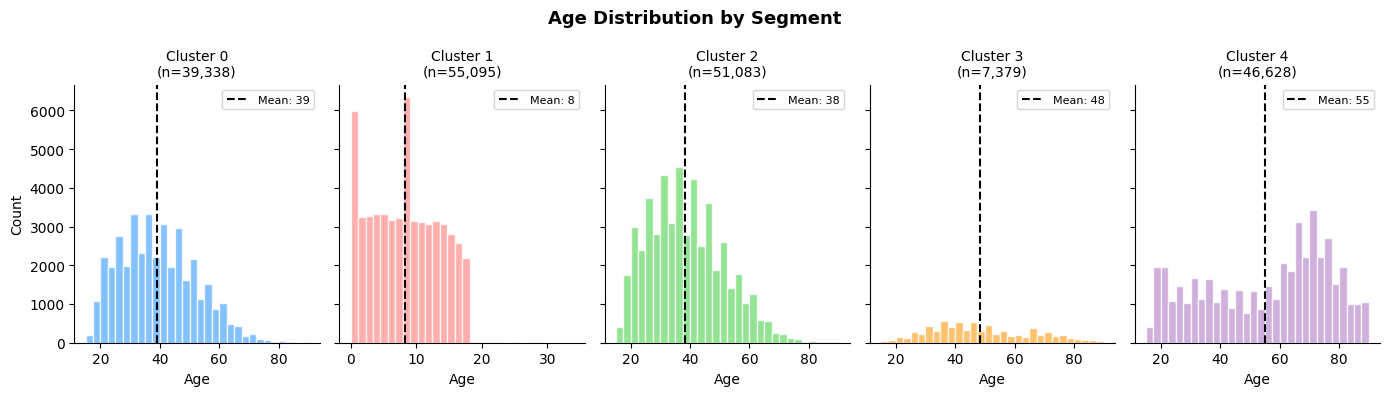

In [63]:
# age distribution per cluster
fig, axes = plt.subplots(1, FINAL_K, figsize=(14, 4), sharey=True)

for i in range(FINAL_K):
    cluster_data = df_seg[df_seg['cluster'] == i]['age']
    axes[i].hist(cluster_data, bins=30, color=colors[i], alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Cluster {i}\n(n={len(cluster_data):,})', fontsize=10)
    axes[i].set_xlabel('Age')
    axes[i].axvline(cluster_data.mean(), color='black', linestyle='--',
                    linewidth=1.5, label=f'Mean: {cluster_data.mean():.0f}')
    axes[i].legend(fontsize=8)

axes[0].set_ylabel('Count')
plt.suptitle('Age Distribution by Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_age_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

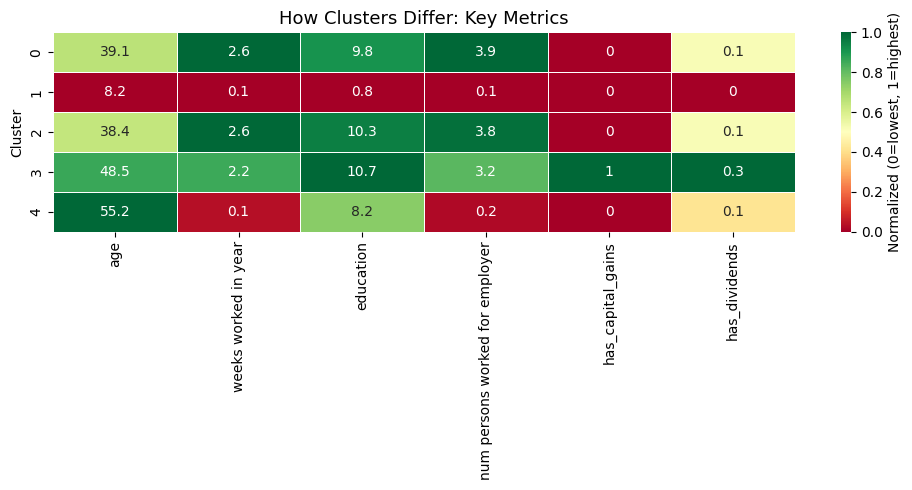

In [64]:
# heatmap showing how clusters differ across key numeric features
heatmap_cols = ['age', 'weeks worked in year', 'education',
                'num persons worked for employer', 'has_capital_gains', 'has_dividends']

cluster_profile = df_seg.groupby('cluster')[heatmap_cols].mean()
cluster_norm    = (cluster_profile - cluster_profile.min()) / \
                  (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_norm, annot=cluster_profile.round(1), fmt='g',
            cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Normalized (0=lowest, 1=highest)'})
plt.title('How Clusters Differ: Key Metrics', fontsize=13)
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('../plots/plot_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

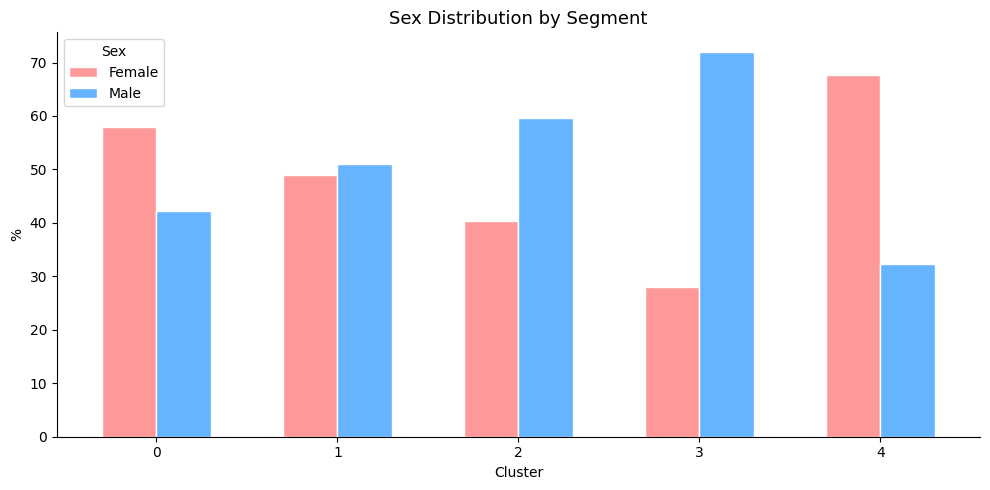

In [65]:
# sex distribution by cluster
sex_cluster = df_seg.groupby(['cluster', 'sex']).size().unstack(fill_value=0)
sex_pct     = sex_cluster.div(sex_cluster.sum(axis=1), axis=0) * 100

sex_pct.plot(kind='bar', figsize=(10, 5), color=['#ff9999', '#66b3ff'],
             width=0.6, edgecolor='white')
plt.title('Sex Distribution by Segment', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.savefig('../plots/plot_sex_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Marketing Briefs

This is what the retail client actually needs.
Based on the cluster profiles, here is who each segment is
and what marketing approach makes sense.

In [67]:
print('MARKETING BRIEFS BY SEGMENT')
print('=' * 70)

segment_names = {
    0: 'Working Adults — Lower Education',
    1: 'Children and Dependents',
    2: 'Working Adults — Some College',
    3: 'High Earner Investors',
    4: 'Retired / Elderly'
}

for i in range(FINAL_K):
    c          = df_seg[df_seg['cluster'] == i]
    income_pct = c['label'].mean() * 100
    avg_age    = c['age'].mean()
    size_pct   = len(c) / len(df_seg) * 100
    edu_num    = c['education'].mode()[0]
    edu_label  = edu_map.get(int(edu_num), str(edu_num))
    has_capgains = c['has_capital_gains'].mean() * 100
    has_divs     = c['has_dividends'].mean() * 100

    print(f'\nSEGMENT {i}: {segment_names.get(i, f"Cluster {i}")} ({size_pct:.0f}% of population)')
    print(f'Profile: avg age {avg_age:.0f}, {c["sex"].mode()[0]}, {c["marital stat"].mode()[0]}')
    print(f'Education: {edu_label} | Occupation: {c["major occupation code"].mode()[0]}')
    print(f'Income: {income_pct:.1f}% earn over $50K | capital gains: {has_capgains:.0f}% | dividends: {has_divs:.0f}%')

    if income_pct > 15:
        print('Segment type: HIGH VALUE TARGET')
        print('Products:  Premium goods, financial services, investment products')
        print('Channels:  Direct mail, email, premium digital')
        print('Message:   Quality, exclusivity, wealth management')
    elif income_pct > 6.2:
        print('Segment type: ABOVE AVERAGE TARGET')
        print('Products:  Mid-range premium, home improvement, family products')
        print('Channels:  Email, social media, online retail')
        print('Message:   Value, reliability, aspiration')
    elif income_pct < 2:
        print('Segment type: NON-TARGET')
        print('Note:      Minimal marketing spend — very low income rate')
    else:
        print('Segment type: BUDGET TARGET')
        print('Products:  Value products, deals, entry-level financial products')
        print('Channels:  Social media, promotions, discount platforms')
        print('Message:   Savings, affordability, practical value')
    print('-' * 70)

MARKETING BRIEFS BY SEGMENT

SEGMENT 0: Working Adults — Lower Education (20% of population)
Profile: avg age 39, Female, Married-civilian spouse present
Education: High school graduate | Occupation: Adm support including clerical
Income: 9.3% earn over $50K | capital gains: 0% | dividends: 15%
Segment type: ABOVE AVERAGE TARGET
Products:  Mid-range premium, home improvement, family products
Channels:  Email, social media, online retail
Message:   Value, reliability, aspiration
----------------------------------------------------------------------

SEGMENT 1: Children and Dependents (28% of population)
Profile: avg age 8, Male, Never married
Education: Children | Occupation: Not in universe
Income: 0.0% earn over $50K | capital gains: 0% | dividends: 0%
Segment type: NON-TARGET
Note:      Minimal marketing spend — very low income rate
----------------------------------------------------------------------

SEGMENT 2: Working Adults — Some College (26% of population)
Profile: avg age 38,

## 15. Save

In [68]:
# saving model and results for the Streamlit app and report
joblib.dump(kmeans,     '../data/kmeans_model.pkl')
joblib.dump(scaler_seg, '../data/scaler_seg.pkl')

df_seg.to_csv('../data/census_segmented.csv', index=False)

# cluster summary csv
cluster_summary = df_seg.groupby('cluster').agg(
    size=('age', 'count'),
    avg_age=('age', 'mean'),
    avg_weeks=('weeks worked in year', 'mean'),
    has_cap_gains=('has_capital_gains', 'mean'),
    has_dividends=('has_dividends', 'mean'),
    income_rate=('label', 'mean')
).round(2)

cluster_summary['income_rate_pct'] = (cluster_summary['income_rate'] * 100).round(1)
cluster_summary.to_csv('../data/cluster_summary.csv')

print('saved:')
print('  data/kmeans_model.pkl')
print('  data/scaler_seg.pkl')
print('  data/census_segmented.csv')
print('  data/cluster_summary.csv')
print('\nsegmentation complete.')

saved:
  data/kmeans_model.pkl
  data/scaler_seg.pkl
  data/census_segmented.csv
  data/cluster_summary.csv

segmentation complete.
